In [10]:
import sys
import os 
import numpy as np
sys.path.append("..")

In [11]:
from src.llm_client import call_llm
from src.embeddings import (
    embed_dataframe,
    get_embedding
)

c:\Stellantis\HomeNestReviews_llm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Stellantis\HomeNestReviews_llm\notebooks\..\src\llm_client.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [12]:
import pandas as pd
df_embeddings = pd.read_csv("../data/raw/homenest_reviews.csv").sample(200, random_state=42).reset_index(drop=True)
df_embeddings

,review_id,product_category,product_name,review_text,star_rating,review_date,verified_purchase
0,1502,Living Room,SoundBar X200 Bluetooth,Five stars. The SoundBar X200 Bluetooth is wel...,4,2023-07-26,True
1,2587,Living Room,SmartTV 55in 4K UHD,Absolutely love my SmartTV 55in 4K UHD! Works ...,4,2023-12-26,True
2,2654,Bathroom,AquaFlow Rainfall Showerhead,The AquaFlow Rainfall Showerhead is easy to cl...,4,2024-09-12,False
3,1056,Bedroom Furniture,DreamRest Memory Foam Mattress,I was skeptical at first but the DreamRest Mem...,5,2023-10-17,True
4,706,Bedroom Furniture,CloudPillow Set (2-pack),I was skeptical at first but the CloudPillow S...,4,2024-12-08,True
...,...,...,...,...,...,...,...
195,1097,Kitchen Appliances,InstaBrew Coffee Maker,Great product. The InstaBrew Coffee Maker exce...,5,2024-08-24,False
196,830,Bathroom,AquaFlow Rainfall Showerhead,The AquaFlow Rainfall Showerhead is easy to cl...,5,2024-05-15,False
197,2806,Living Room,AirPurifier ProMax,MY AIRPURIFIER PROMAX ARRIVED WELL PACKAGED AN...,5,2024-09-01,True
198,3830,Bedroom Furniture,CloudPillow Set (2-pack),Solid quality and great value. The CloudPillow...,4,2023-01-27,False


In [13]:
import re

def clean_for_embedding(text):

    if not isinstance(text, str):
        return ""

    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [14]:
df_embeddings.apply(clean_for_embedding)
df_embeddings

,review_id,product_category,product_name,review_text,star_rating,review_date,verified_purchase
0,1502,Living Room,SoundBar X200 Bluetooth,Five stars. The SoundBar X200 Bluetooth is wel...,4,2023-07-26,True
1,2587,Living Room,SmartTV 55in 4K UHD,Absolutely love my SmartTV 55in 4K UHD! Works ...,4,2023-12-26,True
2,2654,Bathroom,AquaFlow Rainfall Showerhead,The AquaFlow Rainfall Showerhead is easy to cl...,4,2024-09-12,False
3,1056,Bedroom Furniture,DreamRest Memory Foam Mattress,I was skeptical at first but the DreamRest Mem...,5,2023-10-17,True
4,706,Bedroom Furniture,CloudPillow Set (2-pack),I was skeptical at first but the CloudPillow S...,4,2024-12-08,True
...,...,...,...,...,...,...,...
195,1097,Kitchen Appliances,InstaBrew Coffee Maker,Great product. The InstaBrew Coffee Maker exce...,5,2024-08-24,False
196,830,Bathroom,AquaFlow Rainfall Showerhead,The AquaFlow Rainfall Showerhead is easy to cl...,5,2024-05-15,False
197,2806,Living Room,AirPurifier ProMax,MY AIRPURIFIER PROMAX ARRIVED WELL PACKAGED AN...,5,2024-09-01,True
198,3830,Bedroom Furniture,CloudPillow Set (2-pack),Solid quality and great value. The CloudPillow...,4,2023-01-27,False


In [15]:
embeddings = embed_dataframe(df_embeddings)

In [16]:
np.save('../data/processed/review_embeddings.npy', embeddings)
df_embeddings.to_csv('../data/processed/sample_with_ids.csv', index=False)

# Task 4.2 — Cosine Similarity: Understanding Semantic Distance

In [17]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np  

Query → embedding
        ↓
Compare with all embeddings
        ↓
Cosine similarity
        ↓
Return top results

In [18]:
def most_similar(query_text, df, embeddings, top_k=5):
    query_emb = get_embedding(query_text).reshape(1, -1)
    sims = cosine_similarity(query_emb, embeddings)[0]
    top_idx = sims.argsort()[::-1][:top_k]
    results = df.iloc[top_idx][['review_id','product_name','review_text']].copy()
    results['similarity'] = sims[top_idx]
    return results
# Test with several queriesprint(most_similar('motor stopped working', df_sample, embeddings))
print(most_similar('delivery packaging damaged', df_embeddings, embeddings))
print(most_similar('excellent value for money', df_embeddings, embeddings))

     review_id                    product_name  \
10        2465        CloudPillow Set (2-pack)   
15        3544        CloudPillow Set (2-pack)   
53        2847        CloudPillow Set (2-pack)   
151       3908  DreamRest Memory Foam Mattress   
82        4184    FoamPure Electric Toothbrush   

                                           review_text  similarity  
10   Delivery took 3 weeks and the CloudPillow Set ...    0.713890  
15   <p>The CloudPillow Set (2-pack) itself is fine...    0.691524  
53   Very disappointed. The CloudPillow Set (2-pack...    0.681061  
151  Delivery took 3 weeks and the DreamRest Memory...    0.667684  
82   Very disappointed. The FoamPure Electric Tooth...    0.659471  
     review_id                 product_name  \
47        4636            AromaSpa Diffuser   
128       2820            AromaSpa Diffuser   
118        241            AromaSpa Diffuser   
194       2019  MirrorPro LED Vanity Mirror   
68        3683            CrispAir Fryer XL   

  

In [19]:
queries = [
    "motor stopped working",
    "delivery packaging damaged",
    "excellent value for money",
    "battery drains quickly",
    "product stopped functioning"
]

for q in queries:
    print("\nQuery:", q)
    print(most_similar(q, df_embeddings, embeddings).head(3))


Query: motor stopped working
     review_id                  product_name  \
192       3945             AromaSpa Diffuser   
67        2216  FoamPure Electric Toothbrush   
48        3162     WoodCraft Bed Frame Queen   

                                           review_text  similarity  
192  The AromaSpa Diffuser worked for exactly 4 day...    0.726633  
67   The FoamPure Electric Toothbrush worked for ex...    0.725251  
48   Waste of money. The WoodCraft Bed Frame Queen ...    0.718912  

Query: delivery packaging damaged
    review_id              product_name  \
10       2465  CloudPillow Set (2-pack)   
15       3544  CloudPillow Set (2-pack)   
53       2847  CloudPillow Set (2-pack)   

                                          review_text  similarity  
10  Delivery took 3 weeks and the CloudPillow Set ...    0.713890  
15  <p>The CloudPillow Set (2-pack) itself is fine...    0.691524  
53  Very disappointed. The CloudPillow Set (2-pack...    0.681061  

Query: excellent val

# FAISS

In [26]:
import sys
import numpy as np
import pandas as pd
sys.path.append("..")
from src.embeddings import build_faiss_index

# Load embeddings
embeddings = np.load("../data/processed/review_embeddings.npy")

# Load dataframe
df_sample = pd.read_csv("../data/processed/sample_with_ids.csv")

# Build index
index = build_faiss_index(embeddings, df_sample ,save_dir='../data/procesed/faiss/')

Index built with 200 vectors


In [24]:
from src.embeddings import faiss_search

faiss_search(
    "motor stopped working",
    index,
    df_sample,
    top_k=5
)

,review_id,product_category,product_name,review_text,star_rating,review_date,verified_purchase,score
192,3945,Bathroom,AromaSpa Diffuser,The AromaSpa Diffuser worked for exactly 4 day...,1,2024-09-07,True,0.726633
67,2216,Bathroom,FoamPure Electric Toothbrush,The FoamPure Electric Toothbrush worked for ex...,2,2024-04-03,False,0.725251
48,3162,Bedroom Furniture,WoodCraft Bed Frame Queen,Waste of money. The WoodCraft Bed Frame Queen ...,2,2024-06-17,True,0.718912
46,3774,Kitchen Appliances,InstaBrew Coffee Maker,Waste of money. The InstaBrew Coffee Maker mot...,1,2024-03-06,False,0.712942
56,1104,Bathroom,AquaFlow Rainfall Showerhead,Waste of money. The AquaFlow Rainfall Showerhe...,2,2023-08-04,True,0.709827


Without FAISS :  Query -> Compare with all embeddings -> O(N)

With FAISS :   Query  -> vector index search -> O(log N)

200 reviews --> 768-dimensional embeddings


it is not possible to visualize 768 dimensions ,

768 dimensions  --> PCA --> 2 dimensions --> scatter plot

# Task 4.4  Embedding Clusters vs LDA 

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [32]:
embeddings = np.load("../data/processed/review_embeddings.npy")

df_sample = pd.read_csv("../data/processed/sample_with_ids.csv")
df_sample.columns

Index(['review_id', 'product_category', 'product_name', 'review_text',
       'star_rating', 'review_date', 'verified_purchase'],
      dtype='str')

In [29]:
embeddings.shape

(200, 1024)

In [35]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(df_sample["review_text"])

tfidf_matrix = vectorizer.transform(df_sample["review_text"])

In [39]:
lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda_model.fit(tfidf_matrix)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [40]:
topic_probs = lda_model.transform(tfidf_matrix)

df_sample["dominant_topic"] = topic_probs.argmax(axis=1)

In [41]:
df_sample[["review_text","dominant_topic"]].head()

,review_text,dominant_topic
0,Five stars. The SoundBar X200 Bluetooth is wel...,2
1,Absolutely love my SmartTV 55in 4K UHD! Works ...,0
2,The AquaFlow Rainfall Showerhead is easy to cl...,3
3,I was skeptical at first but the DreamRest Mem...,1
4,I was skeptical at first but the CloudPillow S...,3


In [44]:
df_sample.to_csv("../data/processed/sample_with_topics.csv", index=False)

In [45]:
pca = PCA(n_components=2, random_state=42)

coords = pca.fit_transform(embeddings)

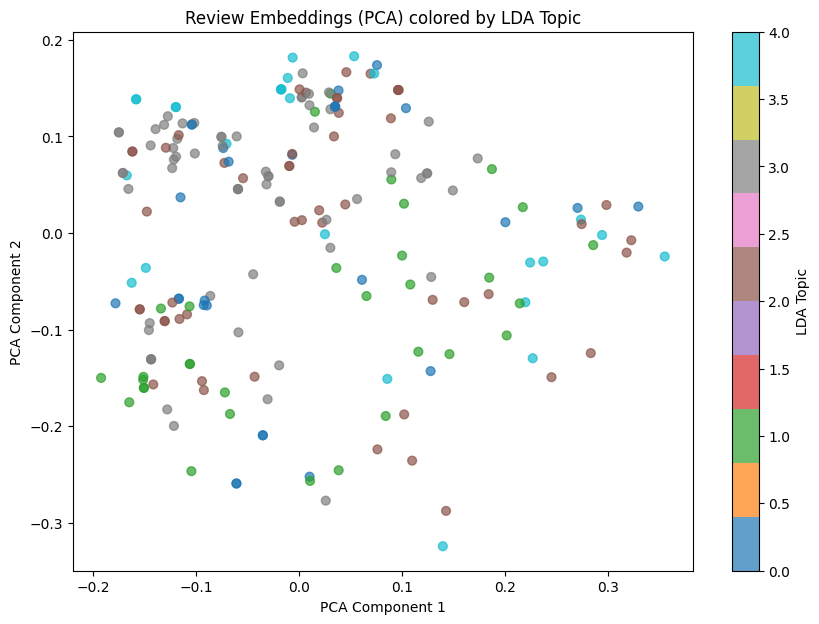

In [46]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    coords[:,0],
    coords[:,1],
    c=df_sample["dominant_topic"],
    cmap="tab10",
    alpha=0.7,
    s=40
)

plt.colorbar(scatter, label="LDA Topic")

plt.title("Review Embeddings (PCA) colored by LDA Topic")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()